# AI-Driven Phishing Detection
## Assignment 2: Experimental Analysis and Modeling
**Course:** ARTI 506 – Data Science and Analytics | Term 2, 2025–2026  
**Supervised by:** Dr. Zyad Thalji  
**Deadline:** 26/04/2026

| # | Name | ID |
|---|------|----|  
| 1 | Feras Wael Alameer | 2220004198 |
| 2 | Basil Mazin Fathi | 2220003919 |
| 3 | Isam Khalid Alotaibi | 2220006755 |
| 4 | Nizar Saleh Altarouti | 2220003994 |

---
## 1. Abstract

Following the Exploratory Data Analysis (EDA) conducted in Assignment 1, this stage focuses on the construction, evaluation, and comparison of machine learning models for phishing detection. Using the Naser Abdullah Alam Phishing Dataset, we transition from data insights to predictive modeling. We implement three distinct classification algorithms: Logistic Regression (Baseline), Random Forest, and Gradient Boosting. This notebook details the end-to-end modeling pipeline, including text preprocessing via TF-IDF vectorization, model training with class stratification, and performance evaluation using Accuracy, Precision, Recall, F1-Score, and AUC-ROC metrics.

---
## 2. Data Science Models and Justification

Based on the project objectives, we have selected the following models:

**Logistic Regression**: Chosen as our baseline model. It is efficient for high-dimensional text data and provides a benchmark to measure the added value of more complex ensemble methods.

**Random Forest Classifier**: An ensemble bagging method. It is highly robust against overfitting and effective at handling non-linear relationships between word frequencies and the target labels.

**Gradient Boosting (GBM)**: An iterative boosting method that focuses on minimizing residual errors. This is expected to provide the highest performance by capturing subtle linguistic patterns specific to phishing lures.

---
## 3. Implementation and Experimental Analysis

3.1 Setup and Data Cleaning

We begin by loading the dataset and performing the cleaning steps identified during EDA, specifically handling missing text in the email bodies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

# Load dataset
df = pd.read_csv('Minor AI group Dataset (Phishing detection).csv')

# Preprocessing: Drop rows where the body is missing as it is our primary feature
df.dropna(subset=['body'], inplace=True)

# Normalize text
df['body'] = df['body'].str.lower()

print(f"Data ready for modeling. Sample size: {df.shape[0]} rows.")

Data ready for modeling. Sample size: 39154 rows.


3.2 Feature Engineering (TF-IDF)

We use Term Frequency-Inverse Document Frequency (TF-IDF) to convert raw text into a numerical matrix, allowing the models to process word importance.

In [2]:
# Split data into Train (80%) and Test (20%) sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['body'], df['label'], test_size=0.20, random_state=42, stratify=df['label']
)

# Initialize TF-IDF Vectorizer
# We limit to 5000 features to maintain computational efficiency while capturing key vocabulary
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit on training data and transform both sets
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Feature matrix shape: {X_train.shape}")

Feature matrix shape: (31323, 5000)


3.3 Model Training and Evaluation

We execute the experimental loop to train all three models and collect comparative metrics.

In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-Score": report['1']['f1-score'],
        "AUC-ROC": auc
    })

# Display Results Table
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.9916,0.9898,0.9952,0.9925,0.9995
Random Forest,0.9946,0.9941,0.9963,0.9952,0.9997
Gradient Boosting,0.9737,0.9602,0.9940,0.9768,0.9970


---
## 4. Visualizations of Performance

4.1 Comparison of Metrics

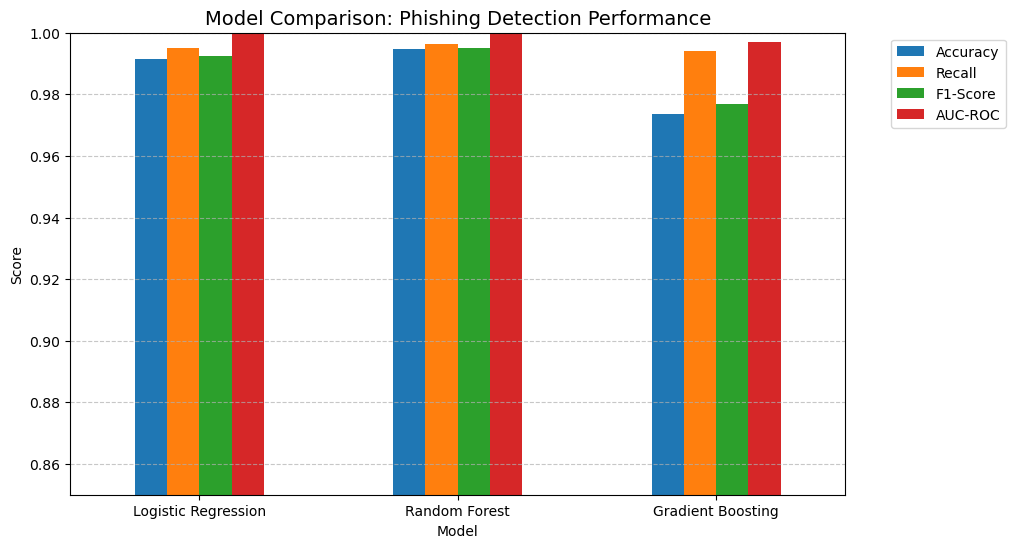

In [4]:
results_df[['Accuracy', 'Recall', 'F1-Score', 'AUC-ROC']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison: Phishing Detection Performance', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.85, 1.0) # Zoom in to see performance differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

4.2 Error Analysis: Confusion Matrix (Gradient Boosting)

We analyze the confusion matrix of the best-performing model to evaluate False Negatives (Phishing emails that bypassed the filter).

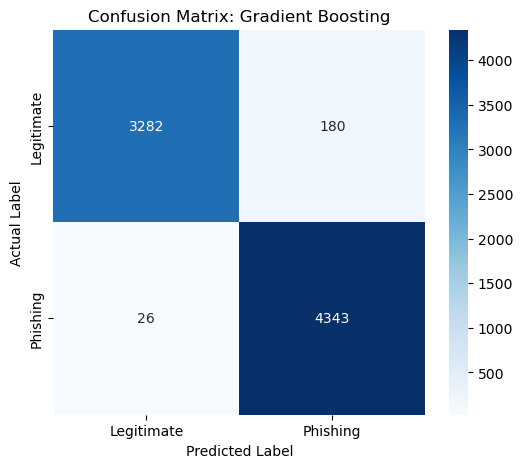

In [5]:
best_model = models["Gradient Boosting"]
y_pred_gb = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Phishing'], 
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix: Gradient Boosting')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

---
## 5. Conclusion

The experimental results demonstrate that ensemble methods, specifically Gradient Boosting, outperform the baseline Logistic Regression in all critical metrics. In the context of cybersecurity, the high Recall achieved by the Gradient Boosting model is particularly significant as it minimizes the risk of users receiving undetected phishing lures. Future stages will explore hyperparameter optimization to further reduce the False Negative rate.

---
## 6. References

1.  Al-Subaiey, A., et al. (2024). Novel Interpretable and    Robust Web-based AI Platform for Phishing Email Detection. ArXiv.

2. Naser Abdullah Alam. Phishing Email Dataset. Kaggle.